# BDA Practica 1 - Model Results

This notebook compares the two integrated Part5 pipelines that consume the same unified dataset built from Sulianova, CDC, and Cleveland.

In [1]:
from pathlib import Path
import json
import pandas as pd

def locate_project_root(start: Path) -> Path:
    current = start.resolve()
    for _ in range(8):
        if (current / 'run_all_pipeline.py').exists():
            return current
        current = current.parent
    raise FileNotFoundError('Could not locate project root')

PROJECT_ROOT = locate_project_root(Path.cwd())
REPORTS_DIR = PROJECT_ROOT / 'Part5_Analysis_zone' / 'reports'

integrated_core = json.loads((REPORTS_DIR / 'integrated_core_report.json').read_text())
integrated_enriched = json.loads((REPORTS_DIR / 'integrated_enriched_report.json').read_text())
summary = json.loads((REPORTS_DIR / 'summary_report.json').read_text())

print('Loaded reports from:', REPORTS_DIR)
print('Integrated core selected model:', integrated_core['selected_model'])
print('Integrated enriched selected model:', integrated_enriched['selected_model'])

Loaded reports from: /home/stargix/Desktop/uni/BDA/bda-practica1/Part5_Analysis_zone/reports
Integrated core selected model: rf_balanced
Integrated enriched selected model: rf_balanced


In [4]:
comparison = pd.DataFrame([
    {'pipeline': 'integrated_core_test', **integrated_core['test_metrics']},
    {'pipeline': 'integrated_enriched_test', **integrated_enriched['test_metrics']}
])

comparison[['pipeline', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']]

,pipeline,accuracy,precision,recall,f1,roc_auc,pr_auc
0,integrated_core_test,0.787548,0.434707,0.606693,0.506499,0.817092,0.492790
1,integrated_enriched_test,0.836883,0.539618,0.628515,0.580684,0.869401,0.625228


In [5]:
source_mix = pd.DataFrame([
    {'pipeline': 'integrated_core', **integrated_core['source_distribution']},
    {'pipeline': 'integrated_enriched', **integrated_enriched['source_distribution']}
])

source_mix

,pipeline,heart_disease_health_indicators,cardiovascular_disease,heart_disease_cleveland
0,integrated_core,253680,68610,297
1,integrated_enriched,253680,68610,297


In [6]:
feature_sets = pd.DataFrame([
    {
        'pipeline': 'integrated_core',
        'decision_threshold': integrated_core['decision_threshold'],
        'n_features': len(integrated_core['features']),
        'feature_list': ', '.join(integrated_core['features']),
    },
    {
        'pipeline': 'integrated_enriched',
        'decision_threshold': integrated_enriched['decision_threshold'],
        'n_features': len(integrated_enriched['features']),
        'feature_list': ', '.join(integrated_enriched['features']),
    },
])

feature_sets[['pipeline', 'decision_threshold', 'n_features', 'feature_list']]

,pipeline,decision_threshold,n_features,feature_list
0,integrated_core,0.638899,9,"age_years_proxy, bmi, gender, high_blood_press..."
1,integrated_enriched,0.605461,17,"age_years_proxy, bmi, systolic_bp, diastolic_b..."


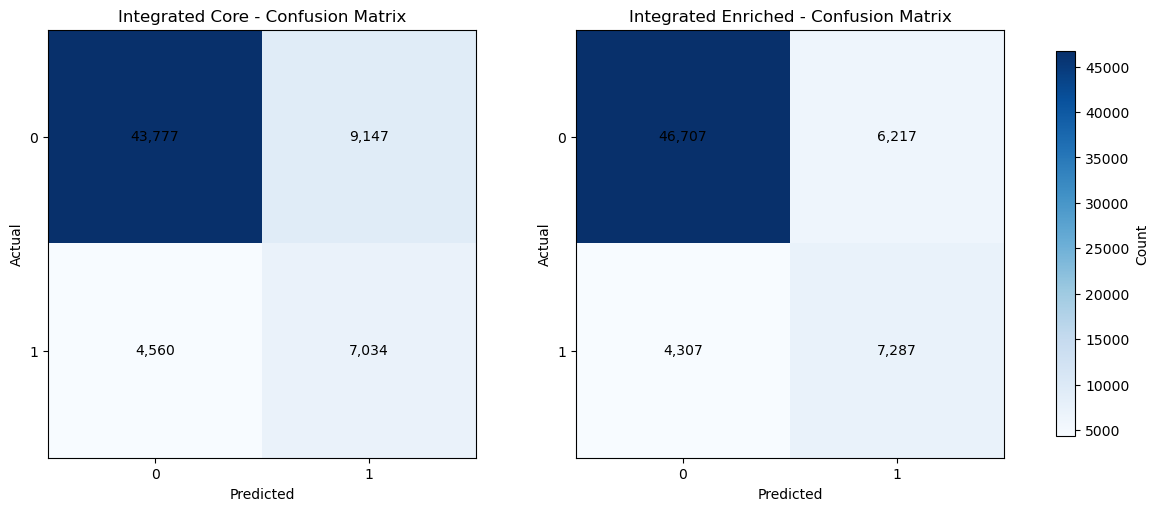

In [3]:
import matplotlib.pyplot as plt
import numpy as np

pipelines = [
    ("Integrated Core", integrated_core),
    ("Integrated Enriched", integrated_enriched),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, (name, report) in zip(axes, pipelines):
    cm = np.array(report["test_metrics"]["confusion_matrix"])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])

    ax.set_yticklabels(["0", "1"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="black")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.9, label="Count")
plt.show()

## Interpretation notes

- Both pipelines consume the same unified `risk_model_input` table.
- The integrated core pipeline acts as the cleaner baseline because it only uses robust harmonized features.
- The integrated enriched pipeline tests whether a wider reconciled feature set improves predictive performance.
- Comparing both pipelines isolates the analytical effect of feature scope while keeping the data source fixed.